# 🐈‍⬛ A/B тест для Cookie Cats

Выполнила: [Анастасия Солдатова](https://github.com/FragileMouse)


Дата: 18.06.2026

Целью данного проекта является изучение влияния перемещения ворот с 30-го на 40-й уровень на следующие метрики: суммарное количество сыгранных раундов за 2 недели после установки игры, ретеншн первого дня и ретеншн седьмого дня. По итогам разведки и проверки гипотез было выявлено отсутствие статистически значимых различий между показателями групп. Рекомендовано оставить текущую версию, а также сместить фокус на онбординг до ворот (до 30 уровня).

Датасет взят из открытого доступа с Kaggle и досупен по [ссылке](https://www.kaggle.com/datasets/mursideyarkin/mobile-games-ab-testing-cookie-cats/data).

# Словарь

**Cookie Cats** — это мобильная игра-головоломка в жанре «три в ряд».

**Ворота (gates)** — это игровые точки, которые заставляют игрока сделать паузу. При их появлении пользователь должен либо подождать определённое время, прежде чем сможет продвинуться дальше, либо совершить покупку в приложении.

**Раунд** — это отдельное прохождение уровня.

**Ретеншн** — вернулся ли игрок на N день.

# Загрузка и предпросмотр данных

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
path = 'https://raw.githubusercontent.com/FragileMouse/Mobile_Games_A-B_Testing_Cookie_Cats/refs/heads/main/data/cookie_cats.csv'
df = pd.read_csv(path)
display(df.head())
display(df.info())

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          90189 non-null  int64 
 1   version         90189 non-null  object
 2   sum_gamerounds  90189 non-null  int64 
 3   retention_1     90189 non-null  bool  
 4   retention_7     90189 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 2.2+ MB


None

In [3]:
print(f'↪︎ Количество наблюдений: {df.shape[0]}')
print(f'↪︎ Количество пропусков: {df.isnull().sum().sum()}')
print(f'↪︎ Количество повторяющихся строк: {df.duplicated().sum()}')
print(f'↪︎ Количество повторяющихся id пользователей: {df['userid'].duplicated().sum()}')
print(f'↪︎ Группы: {', '.join(df['version'].unique())}')
print(f'↪︎ Диапазон сыгранных за 14 дней раундов: от {df['sum_gamerounds'].min()} до {df['sum_gamerounds'].max()}.')

↪︎ Количество наблюдений: 90189
↪︎ Количество пропусков: 0
↪︎ Количество повторяющихся строк: 0
↪︎ Количество повторяющихся id пользователей: 0
↪︎ Группы: gate_30, gate_40
↪︎ Диапазон сыгранных за 14 дней раундов: от 0 до 49854.


# Обработаем выбросы

Единственное место, где могут быть выбросы - это количество сыгранных раундов.


In [4]:
#Посмотрим на сыгранные раунды.
group_describe = df.groupby('version')['sum_gamerounds'].describe()
group_describe.loc['Всего'] = df['sum_gamerounds'].describe()

group_describe.round(2)

,count,mean,std,min,25%,50%,75%,max
version,,,,,,,,
gate_30,44700.0,52.46,256.72,0.0,5.0,17.0,50.0,49854.0
gate_40,45489.0,51.30,103.29,0.0,5.0,16.0,52.0,2640.0
Всего,90189.0,51.87,195.05,0.0,5.0,16.0,51.0,49854.0


Максимальное значение: 49854 раундов
Чтобы сыграть такое количество раундов за 14 дней (без перерывов!), нужно тратить на раунд 24 секунд.


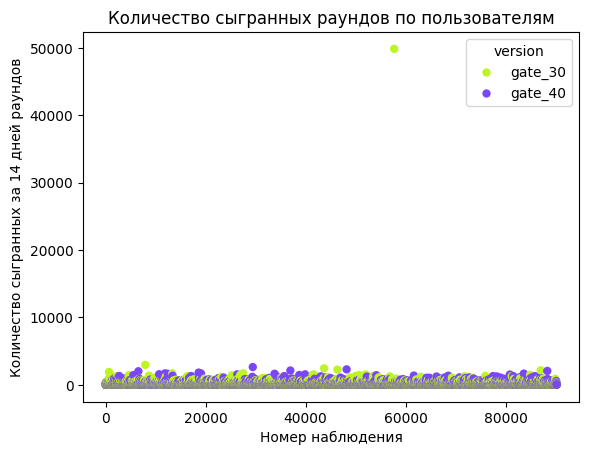

In [5]:
sns.scatterplot(
    data=df.reset_index(),
    x='index',
    y='sum_gamerounds',
    hue='version',
    palette=['#BDF522', '#7B46F8'],
    linewidth = 0
).set(
    xlabel='Номер наблюдения',
    ylabel='Количество сыгранных за 14 дней раундов',
    title='Количество сыгранных раундов по пользователям'
)

print(f'Максимальное значение: {df['sum_gamerounds'].max()} раундов')
print(f'Чтобы сыграть такое количество раундов за 14 дней (без перерывов!), нужно тратить на раунд {round((14*24*60*60)/df['sum_gamerounds'].max())} секунд.')
print('='*65)

In [6]:
#Посмотрим на эту строку
df[df['sum_gamerounds'] == df['sum_gamerounds'].max()]

,userid,version,sum_gamerounds,retention_1,retention_7
57702,6390605,gate_30,49854,False,True


In [7]:
#Он еще и на следующий день не вернулся, точно невозможно физически. Либо робот, либо сбой. Удаляем.
df = df[df['sum_gamerounds'] < df['sum_gamerounds'].max()]

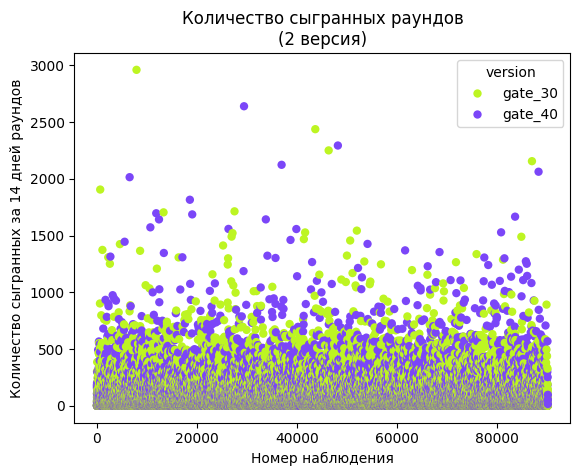

In [8]:
sns.scatterplot(
    data=df.reset_index(),
    x='index',
    y='sum_gamerounds',
    hue='version',
    palette=['#BDF522', '#7B46F8'],
    linewidth = 0
).set(
    xlabel='Номер наблюдения',
    ylabel='Количество сыгранных за 14 дней раундов',
    title='Количество сыгранных раундов\n(2 версия)'
)

print('='*65)

In [9]:
print(f'Новое максимальное значение: {df['sum_gamerounds'].max()} раундов')
print(f'Допустим человек играет по 4 часа каждый день, тогда на раунд уходит около {round((14*5*60)/df['sum_gamerounds'].max(), 2)} минуты.')

Новое максимальное значение: 2961 раундов
Допустим человек играет по 4 часа каждый день, тогда на раунд уходит около 1.42 минуты.


Эти значения вполне реальны (Учитывая что раунд можно досрочно прервать). Остальные значения мы не будем трогать, поскольку они вполне реалистичны. Было достаточно долгое размышление по поводу того, что делать с наблюдениями с малым количеством раундов (близких к нулю), однако в итоге было решено оставить, поскольку иначе мы исказим результаты, включив только активных пользователей.

# Анализ состава групп

Абсолютная разница: 790 пользователей
Относительная разница: 0.88% пользователей


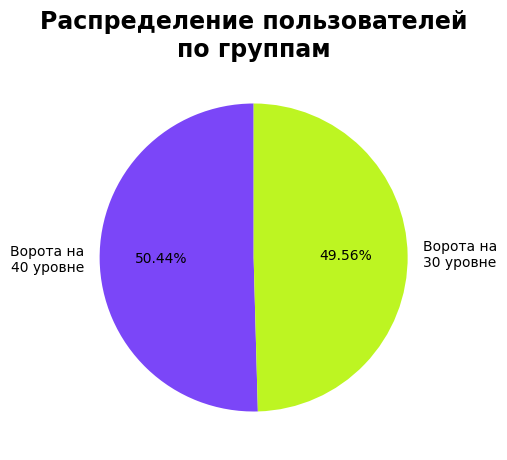

In [10]:
#Посмотрим распределение по группам
df['version'].value_counts().plot.pie(
    figsize = (5, 5),
    colors = ['#7B46F8', '#BDF522'],
    labels = ['Ворота на\n40 уровне', 'Ворота на\n30 уровне'],
    startangle = 90,
    ylabel = '',
    autopct='%1.2f%%'
).set_title(
    'Распределение пользователей\nпо группам',
    fontsize = 17,
    fontweight = 'bold'
)

print(f'Абсолютная разница: {abs(df[df['version'] == 'gate_30'].shape[0] - df[df['version'] == 'gate_40'].shape[0])} пользователей')
print(f'Относительная разница: {round(abs(df[df['version'] == 'gate_30'].shape[0] - df[df['version'] == 'gate_40'].shape[0])/df.shape[0]*100, 2)}% пользователей')
print('='*65)

Распределение достаточно равномерное, перекос менее 1% пользователей.

## По количеству сыгранных раундов

In [11]:
#Еще раз посмотрм на таблицу (уже исправленную).
group_describe = df.groupby('version')['sum_gamerounds'].describe()
group_describe.loc['Всего'] = df['sum_gamerounds'].describe()

group_describe.round(2)

,count,mean,std,min,25%,50%,75%,max
version,,,,,,,,
gate_30,44699.0,51.34,102.06,0.0,5.0,17.0,50.0,2961.0
gate_40,45489.0,51.30,103.29,0.0,5.0,16.0,52.0,2640.0
Всего,90188.0,51.32,102.68,0.0,5.0,16.0,51.0,2961.0


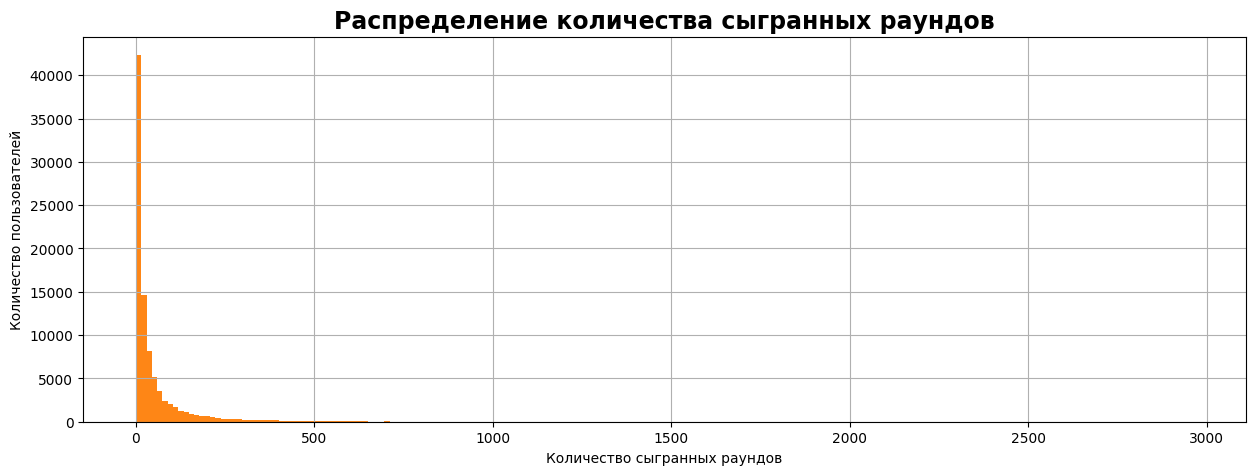

In [12]:
df['sum_gamerounds'].plot.hist(
    bins = 200,
    figsize = (15, 5),
    xlabel = 'Количество сыгранных раундов',
    ylabel = 'Количество пользователей',
    color = '#FE8616',
    grid = True
).set_title(
    'Распределение количества сыгранных раундов',
    fontsize = 17,
    fontweight = 'bold'
)

print('='*65)

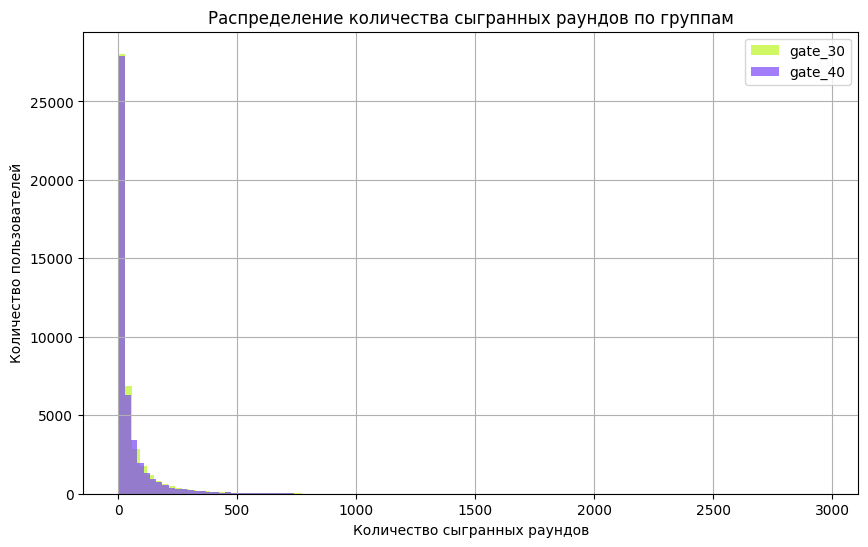

In [13]:
df.groupby('version')['sum_gamerounds'].plot.hist(
    bins=100,
    alpha=0.7,
    xlabel='Количество сыгранных раундов',
    ylabel='Количество пользователей',
    grid=True,
    legend=True,
    figsize=(10, 6),
    color = {'gate_40':'#7B46F8', 'gate_30':'#BDF522'},
    title = 'Распределение количества сыгранных раундов по группам'
    #xlim = [0, 3000]
)

print('='*65)

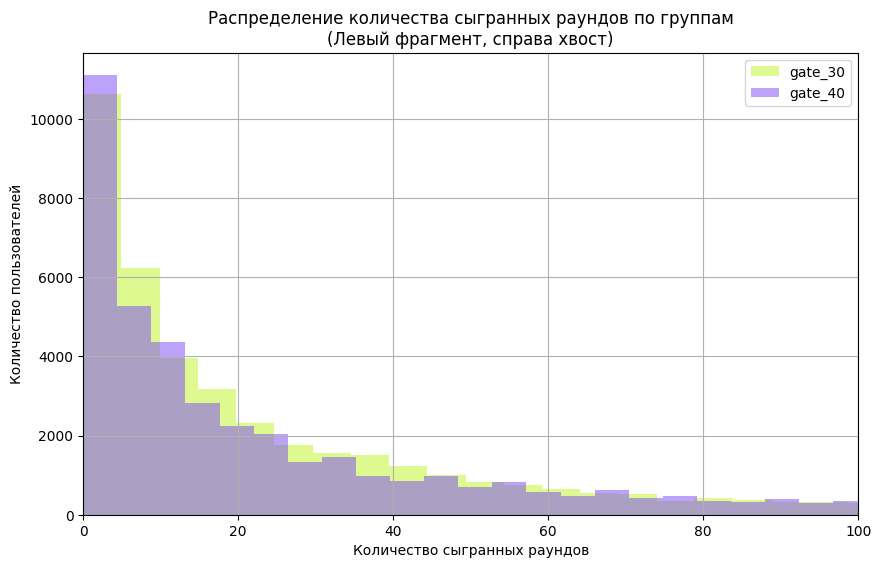

In [14]:
df.groupby('version')['sum_gamerounds'].plot.hist(
    bins=600,
    alpha=0.5,
    xlabel='Количество сыгранных раундов',
    ylabel='Количество пользователей',
    grid=True,
    legend=True,
    figsize=(10, 6),
    color = {'gate_40':'#7B46F8', 'gate_30':'#BDF522'},
    title = 'Распределение количества сыгранных раундов по группам\n(Левый фрагмент, справа хвост)',
    xlim = [0,100]
)

print('='*65)

Абсолютная разница составляет: 120
Относительная разница составляет: 0.13%


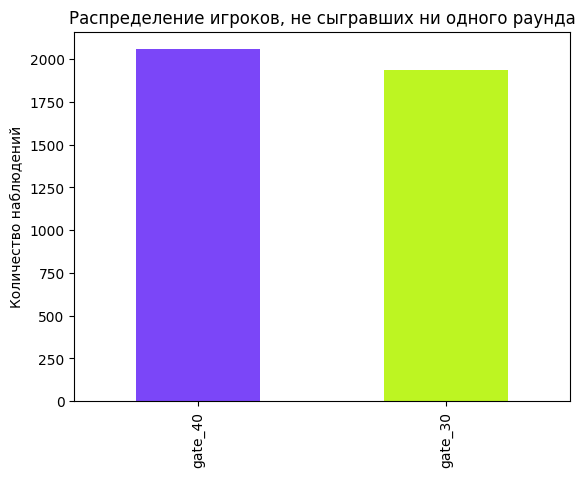

In [15]:
df[df['sum_gamerounds'] == 0]['version'].value_counts().plot.bar(
    xlabel = '',
    ylabel = 'Количество наблюдений',
    color = ['#7B46F8', '#BDF522'],
    title = 'Распределение игроков, не сыгравших ни одного раунда'

)

print(f'Абсолютная разница составляет: {abs(df[(df['sum_gamerounds'] == 0) & (df['version'] == 'gate_30')].shape[0] - df[(df['sum_gamerounds'] == 0) & (df['version'] == 'gate_40')].shape[0])}')
print(f'Относительная разница составляет: {round((abs(df[(df['sum_gamerounds'] == 0) & (df['version'] == 'gate_30')].shape[0] - df[(df['sum_gamerounds'] == 0) & (df['version'] == 'gate_40')].shape[0]))/df.shape[0]*100, 2)}%')
print('=' * 60)

In [16]:
print(f'Из {df.shape[0]} игроков {df[df['sum_gamerounds'] == 0].shape[0]} ({round(df[df['sum_gamerounds'] == 0].shape[0]/df.shape[0]*100, 2)}%) не сыграли ни разу, {df[df['sum_gamerounds'] < 10].shape[0]} игроков ({round(df[df['sum_gamerounds'] < 10].shape[0]/df.shape[0]*100, 2)}%) сыграли менее 10 раз  (из тех, кто сыграл хотя бы 1 раз - {df[(df['sum_gamerounds'] > 0) & (df['sum_gamerounds'] < 10)].shape[0]} игроков или {round(df[(df['sum_gamerounds'] > 0) & (df['sum_gamerounds'] < 10)].shape[0] / df[(df['sum_gamerounds'] > 0)].shape[0] * 100, 2)}%), а меньше 20 раз {df[df['sum_gamerounds'] < 20].shape[0]} ({round(df[df['sum_gamerounds'] < 20].shape[0]/df.shape[0]*100, 2)}%) игроков (из тех, кто сыграл хотя бы 1 раз - {df[(df['sum_gamerounds'] > 0) & (df['sum_gamerounds'] < 20)].shape[0]} игроков или {round(df[(df['sum_gamerounds'] > 0) & (df['sum_gamerounds'] < 20)].shape[0] / df[(df['sum_gamerounds'] > 0)].shape[0] * 100, 2)}%)')

Из 90188 игроков 3994 (4.43%) не сыграли ни разу, 34237 игроков (37.96%) сыграли менее 10 раз  (из тех, кто сыграл хотя бы 1 раз - 30243 игроков или 35.09%), а меньше 20 раз 48769 (54.07%) игроков (из тех, кто сыграл хотя бы 1 раз - 44775 игроков или 51.95%)


In [17]:
print(f'Из {df.shape[0]} игроков меньше 30 раз сыграло {df[df['sum_gamerounds'] < 30].shape[0]} ({round(df[df['sum_gamerounds'] < 30].shape[0]/df.shape[0]*100, 2)}%) игроков (из тех, кто сыграл хотя бы 1 раз - {df[(df['sum_gamerounds'] > 0) & (df['sum_gamerounds'] < 30)].shape[0]} игроков или {round(df[(df['sum_gamerounds'] > 0) & (df['sum_gamerounds'] < 30)].shape[0] / df[(df['sum_gamerounds'] > 0)].shape[0] * 100, 2)}%)')

Из 90188 игроков меньше 30 раз сыграло 56920 (63.11%) игроков (из тех, кто сыграл хотя бы 1 раз - 52926 игроков или 61.4%)


В категории "30" скрыты значения больше 117.5
В категории "40" скрыты значения больше 122.5
(Выбросы по методу IQR)
Чтобы сосредоточиться на основной массе наблюдений


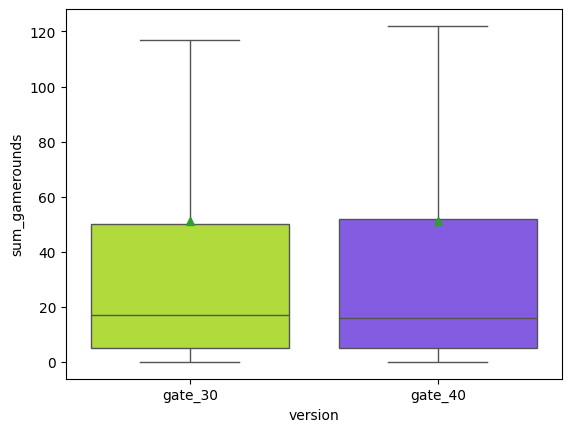

In [18]:
sns.boxplot(
    x = df['version'],
    y = df['sum_gamerounds'],
    hue = df['version'],
    order=['gate_30', 'gate_40'],
    showfliers=False,
    showmeans = True,
    palette=['#BDF522', '#7B46F8']
)

print(f'В категории "30" скрыты значения больше {group_describe.loc['gate_30', '75%'] + 1.5 * (group_describe.loc['gate_30', '75%'] - group_describe.loc['gate_30', '25%'])}')
print(f'В категории "40" скрыты значения больше {group_describe.loc['gate_40', '75%'] + 1.5 * (group_describe.loc['gate_40', '75%'] - group_describe.loc['gate_40', '25%'])}')
print('(Выбросы по методу IQR)')
print('Чтобы сосредоточиться на основной массе наблюдений')
print('='*65)

Распредение по форме экспоненциальное, приблизительно одинаковое в обоих группах. Предположительно, на среднее количество суммарно пройденных раундов вариант расположения ворот не влияет.

## По ретеншену

In [19]:
retention_table = pd.DataFrame(
    {
        'all' : [
            df.shape[0],
            df['retention_1'].sum(),
            df['retention_7'].sum()
        ],
        'gate_30' : [
            df[df['version'] == 'gate_30'].shape[0],
            df[df['version'] == 'gate_30']['retention_1'].sum(),
            df[df['version'] == 'gate_30']['retention_7'].sum()
        ],
        'gate_40' : [
            df[df['version'] == 'gate_40'].shape[0],
            df[df['version'] == 'gate_40']['retention_1'].sum(),
            df[df['version'] == 'gate_40']['retention_7'].sum()
        ],
    },
    index = ['R0', 'R1', 'R7']
)

display(retention_table)

,all,gate_30,gate_40
R0,90188,44699,45489
R1,40153,20034,20119
R7,16780,8501,8279


In [20]:
(8501 - 8279)/16780	*100

1.3230035756853398

In [21]:
retention_table_perc = pd.DataFrame(
    {
        'all' : [
            100,
            round(retention_table.loc['R1', 'all']/retention_table.loc['R0', 'all']*100, 2),
            round(retention_table.loc['R7', 'all']/retention_table.loc['R0', 'all']*100, 2)
        ],
        'gate_30' : [
            100,
            round(retention_table.loc['R1', 'gate_30']/retention_table.loc['R0', 'gate_30']*100, 2),
            round(retention_table.loc['R7', 'gate_30']/retention_table.loc['R0', 'gate_30']*100, 2)

        ],
        'gate_40' : [
            100,
            round(retention_table.loc['R1', 'gate_40']/retention_table.loc['R0', 'gate_40']*100, 2),
            round(retention_table.loc['R7', 'gate_40']/retention_table.loc['R0', 'gate_40']*100, 2)
        ],
    },
    index = ['R0', 'R1', 'R7']
)

display(retention_table_perc)

,all,gate_30,gate_40
R0,100.00,100.00,100.00
R1,44.52,44.82,44.23
R7,18.61,19.02,18.20


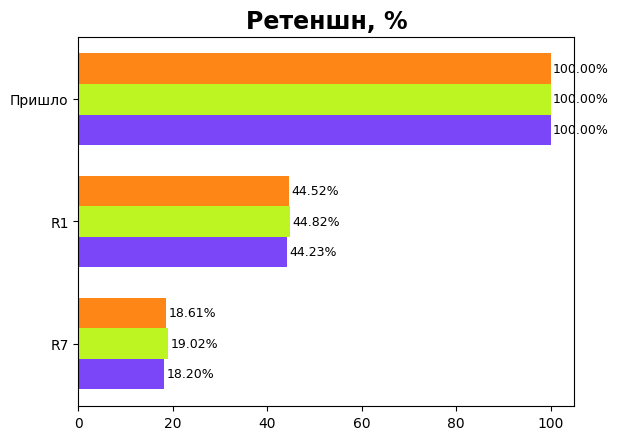

In [22]:
bar_width = 0.25
x = np.arange(len(retention_table_perc))

bars1 = plt.barh(x - bar_width, retention_table_perc['all'], height=bar_width, label='all', color = '#fe8616')
bars2 = plt.barh(x, retention_table_perc['gate_30'], height=bar_width, label='gate_30', color = '#bdf522')
bars3 = plt.barh(x + bar_width, retention_table_perc['gate_40'], height=bar_width, label='gate_40', color = '#7b46f8')

plt.yticks(x, ['Пришло', 'R1', 'R7'])
plt.title('Ретеншн, %', fontsize = 17, fontweight = 'bold')

for bar in bars1 + bars2 + bars3:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2,
             f'{width:.2f}%', va='center', fontsize=9)

plt.gca().invert_yaxis()
plt.show()

В обоих группах ретеншн не очень сильно отличается: на первый день всего 0.2%, а на 7 разница около 0.8%. Предположительно разницы особо нет, осталось проверить статистически.

# Статистические тесты

## Суммарное количество раундов

*Что хочу узнать?* Влияет ли расположение ворот (на 30-м или 40-м уровне) на суммарное количество раундов, которое проходит пользователь.

*Нулевая гипотеза*: отсутствуют статистически значимые различия между распределением суммарного количества пройденных раундов в двух группах.

*Критерий:* U-критерий Манна-Уитни (т.к. выборка не подчиняется нормальному распределению + большой хвост)

*Уровень значимости:* 0.05 (стандартный)

In [23]:
from scipy.stats import mannwhitneyu

v_30 = df[df['version'] == 'gate_30']['sum_gamerounds']
v_40 = df[df['version'] == 'gate_40']['sum_gamerounds']

stat, p_value = mannwhitneyu(v_30, v_40, alternative='two-sided')

print(f'U-статистика: {stat}')
print(f'p_value = {p_value}')
print('Уровень значимости = 0.05 (стандартный)')

U-статистика: 1024285761.5
p_value = 0.05089155279145376
Уровень значимости = 0.05 (стандартный)


Формально, у нас нет оснований отвергать нулевую гипотезу (о том что разницы нет). Однако у p-value сильно пограничное состояние. Кроме того, из-за большой выборки и большого количества дублирующихся значений, критерий не очень надежен. Посмотрим на размер эффекта.

In [24]:
#Вероятность превосходства
print('Вероятность того, что случайно выбранный человек из одной группы сыграл больше раундов, чем случайный человек из второй:', round(stat/(v_30.shape[0]*v_40.shape[0]), 4)*100, '%')

Вероятность того, что случайно выбранный человек из одной группы сыграл больше раундов, чем случайный человек из второй: 50.38 %


Значение практически в 50% говорит об отсутстии эффекта.

## Ретеншн

Это бинарная переменная. Мы будем работать через таблицы сопряженности.

### R1

*Что хочу узнать?* Влияет ли расположение ворот (на 30-м или 40-м уровне) на то,вернется ли пользователь в игру на следующий день.

*Нулевая гипотеза*: расположение ворот не влияет на ретеншн на следующий день

*Инструменты:* Критерий Пирсона (χ²), коэффициент Краммера

*Уровень значимости:* 0.05 (стандартный)

In [25]:
from scipy.stats import chi2_contingency

cross_tab_r1 = pd.crosstab(df['version'], df['retention_1'])

display(cross_tab_r1)

# Проведем тест хи-квадрат
chi2, p, dof, expected = chi2_contingency(cross_tab_r1)

print(f'Статистика χ²: {chi2:.4f}')
print(f'p-значение: {p:.6f}')

print(f'Коэффициент Краммера: {round((chi2/(cross_tab_r1.sum().sum()*1))**0.5, 3)}')

retention_1,False,True
version,,
gate_30,24665,20034
gate_40,25370,20119


Статистика χ²: 3.1698
p-значение: 0.075010
Коэффициент Краммера: 0.006


У нас нет оснований отвергнуть нулевую гипотезу. Коэффициент Краммера показал незначительную связь.

### R7

*Что хочу узнать?* Влияет ли расположение ворот (на 30-м или 40-м уровне) на то,вернется ли пользователь в игру через неделю.

*Нулевая гипотеза*: расположение ворот не влияет на ретеншн через неделю

*Инструменты:* Критерий Пирсона (χ²), коэффициент Краммера

*Уровень значимости:* 0.05 (стандартный)

In [26]:
from scipy.stats import chi2_contingency

cross_tab_r7 = pd.crosstab(df['version'], df['retention_7'])

display(cross_tab_r7)

# Проведем тест хи-квадрат
chi2, p, dof, expected = chi2_contingency(cross_tab_r7)

print(f'Статистика χ²: {chi2:.4f}')
print(f'p-значение: {p:.6f}')

print(f'Коэффициент Краммера: {round((chi2/(cross_tab_r7.sum().sum()*1))**0.5, 3)}')

retention_7,False,True
version,,
gate_30,36198,8501
gate_40,37210,8279


Статистика χ²: 9.9153
p-значение: 0.001639
Коэффициент Краммера: 0.01


Оснований отвергнуть нулевую гипотезу нет, сила связи еще слабее, чем у ретеншена первого дня.

# Выводы

В ходе анализа собранных данных не было обнаружено статистически значимой связи между расположением ворот на 30 или 40 уровне и каким-либо из рассматриваемых параметров (суммарного количества сыгранных за 14 дней раундов, ретеншена 1-го дня, ретеншена 7-го дня) при уровне значимости равном 0,05.

|Метрика|всего|30-й уровень|40-й уровень|Абсолютная разница|Относительная разница|
|---|---|---|---|---|---|
|Сумма сыгранных раундов (медиана)|16|17|16|Распределения визуально схожи| большой хвост слева|
|Ретеншн первого дня|44.52%|44.82%|44.23%|85|0.21%|
|Ретеншн седьмого дня|18.61%|19.02%|18.20%|222|1.32%|

Рекомендуется **оставить ворота на 30 уровне** и **сфокусироваться на онбординге** до 30-го уровня (менее трети пользователей в целом доходят до ворот)